L'objectif ici est de se placer purement en vision métier : on s'intéresse à définir le risque d'un encours réel
C'est-à-dire que je vais uniquement regarder les clients ayant un BILL_AMT1 > 0.  
Nous sortons ainsi de l'apprentissage :
- les clients sans dette à prédire
- les clients inactifs
- les clients sortis du circuit de gestion classique pour lequels nous n'avons pas le suivi des paiements et des encours de manière correcte

In [1]:
import pandas as pd
from pathlib import Path

# 1. Dossier courant du notebook
current_dir = Path.cwd()

# 2. Retrouve automatiquement la racine du projet (là où se trouve le dossier 'data')
# Remonte l'arborescence jusqu'à trouver le dossier 'data'
root_dir = next(
    p for p in [current_dir] + list(current_dir.parents) if (p / "data").exists()
)

# 3. Chemin vers le fichier
file_path = root_dir / "data" / "cleaned2_creditcard.csv"

# 4. Chargement du CSV
df = pd.read_csv(file_path)

In [2]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'ratio_PAY_AMT1_to_BILL_AMT2', 'ratio_PAY_AMT2_to_BILL_AMT3',
       'ratio_PAY_AMT3_to_BILL_AMT4', 'ratio_PAY_AMT4_to_BILL_AMT5',
       'ratio_PAY_AMT5_to_BILL_AMT6'],
      dtype='str')

In [3]:
# on filtre le dataset utilisé de sorte à ne garder que la population souhaitée : BILL_AMT1 > 0
df= df[(df['BILL_AMT1']>0)]

In [4]:
# Analyse de la distribution de la variable cible dp_nm
print("=== ANALYSE DE LA DISTRIBUTION DE dpnm ===")

# Compter les occurrences de chaque valeur
target_counts = df['dpnm'].value_counts()
print("\nNombre d'observations par classe :")
print(target_counts)

# Calculer les proportions
target_proportions = df['dpnm'].value_counts(normalize=True)
print("\nProportion de chaque classe :")
print(target_proportions)

# Afficher les pourcentages
print("\nPourcentage de chaque classe :")
for class_label, count in target_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Classe {class_label}: {count} observations ({percentage:.2f}%)")

# Vérification si le dataset est équilibré
print("\n=== ÉQUILIBRE DU DATASET ===")
imbalance_ratio = target_counts.min() / target_counts.max()
print(f"Ratio d'équilibre (min/max): {imbalance_ratio:.3f}")

print("\n=== RÉSUMÉ ===")
print(f"Total d'observations : {len(df)}")
print(f"Classes présentes : {sorted(target_counts.index.tolist())}")

=== ANALYSE DE LA DISTRIBUTION DE dpnm ===

Nombre d'observations par classe :
dpnm
0    21405
1     5993
Name: count, dtype: int64

Proportion de chaque classe :
dpnm
0    0.781261
1    0.218739
Name: proportion, dtype: float64

Pourcentage de chaque classe :
Classe 0: 21405 observations (78.13%)
Classe 1: 5993 observations (21.87%)

=== ÉQUILIBRE DU DATASET ===
Ratio d'équilibre (min/max): 0.280

=== RÉSUMÉ ===
Total d'observations : 27398
Classes présentes : [0, 1]


In [5]:
from sklearn.model_selection import train_test_split

# Séparation test / entrainement
y = df['dpnm']
X = df.drop('dpnm', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
# Séparation des colonnes numériques et catégorielles
num_col = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
cat_col = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

Les colonnes catégorielles sont dejà en integer donc il est inutile de les encoder  

Je commence par un apprentissage sur le F1 score

In [7]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Ratio pour la gestion du déséquilibre de classe
scale_pos = (100 - percentage) / percentage

# 2. Transformateur d'isolation : Standardisation uniquement sur num_col
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        ('cat', 'passthrough', cat_col),
    ]
)

# 3. Dictionnaire des modèles (Utilisation de CalibratedClassifierCV pour SVM)
models = {
    'LogisticRegression': make_pipeline(
        preprocessor,
        LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ),
    ),
    'SVM': make_pipeline(
        preprocessor,
        CalibratedClassifierCV(
            estimator=SVC(class_weight='balanced', random_state=42),
            ensemble=False,
        ),
    ),
    'MLPClassifier': make_pipeline(
        preprocessor,
        MLPClassifier(
            hidden_layer_sizes=(50, 25),
            max_iter=500,
            random_state=42,
            early_stopping=True,
        ),
    ),
    'KNN': make_pipeline(
        preprocessor,
        KNeighborsClassifier(
            n_neighbors=5,
            n_jobs=-1,
        ),
    ),
    'RandomForest': make_pipeline(
        preprocessor,
        RandomForestClassifier(
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
    ),
    'CatBoost': make_pipeline(
        preprocessor,
        CatBoostClassifier(
            scale_pos_weight=scale_pos,
            random_state=42,
            verbose=0,
            thread_count=-1,
        ),
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
importances_dict = {}
fitted_models = {}

print("Spot-check avec mesure du surapprentissage & extraction des poids...\n")

# 4. Boucle d'évaluation
for name, model in models.items():
    # A. Evaluation CV
    cv_res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        return_train_score=True,
        n_jobs=-1,
    )

    train_score = np.mean(cv_res['train_score'])
    test_score = np.mean(cv_res['test_score'])

    results.append({
        'Modèle': name,
        'F1 Train': round(train_score, 4),
        'F1 Val (Validation)': round(test_score, 4),
        'Écart (Overfit)': round(train_score - test_score, 4),
        'Std Val': round(np.std(cv_res['test_score']), 4),
    })

    # B. Fit final sur l'ensemble X_train
    model.fit(X_train, y_train)
    fitted_models[name] = model

    # C. Extraction des poids d'importance
    clf = model[-1]

    # Déballage si le modèle est encapsulé dans CalibratedClassifierCV
    if isinstance(clf, CalibratedClassifierCV):
        clf_estimator = (
            clf.calibrated_classifiers_[0].estimator
            if hasattr(clf, 'calibrated_classifiers_')
            else clf.estimator
        )
    else:
        clf_estimator = clf

    # Vérification des attributs d'importance
    if hasattr(clf_estimator, 'feature_importances_'):
        raw_imp = clf_estimator.feature_importances_
    elif hasattr(clf_estimator, 'coef_'):
        raw_imp = np.abs(clf_estimator.coef_[0])
    elif hasattr(clf_estimator, 'coefs_'):
        raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
    else:
        print(
            f"  -> {name} : pas de poids d'importance natifs (ex: KNN, SVM RBF)."
        )
        continue

    total = raw_imp.sum()
    importances_dict[name] = (raw_imp / total) * 100 if total > 0 else raw_imp

# 5. Affichage des résultats du Spot-Check
df_results = pd.DataFrame(results).sort_values(
    by='F1 Val (Validation)', ascending=False
)
print("\n--- RÉSULTATS DU SPOT-CHECK ET CONTRÔLE DE L'OVERFITTING ---")
print(df_results.to_string(index=False))

# 6. Affichage du tableau d'importance des variables
features = num_col + cat_col
df_importances = pd.DataFrame(importances_dict, index=features)
if not df_importances.empty:
    df_importances['Moyenne (%)'] = df_importances.mean(axis=1)
    df_importances = df_importances.sort_values(
        by='Moyenne (%)', ascending=False
    ).round(2)

    print('\n--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---')
    print(df_importances.to_string())

Spot-check avec mesure du surapprentissage & extraction des poids...

  -> SVM : pas de poids d'importance natifs (ex: KNN, SVM RBF).
  -> KNN : pas de poids d'importance natifs (ex: KNN, SVM RBF).

--- RÉSULTATS DU SPOT-CHECK ET CONTRÔLE DE L'OVERFITTING ---
            Modèle  F1 Train  F1 Val (Validation)  Écart (Overfit)  Std Val
          CatBoost    0.6992               0.5479           0.1514   0.0133
               SVM    0.5724               0.5437           0.0287   0.0164
      RandomForest    0.9945               0.5381           0.4564   0.0169
     MLPClassifier    0.5148               0.5040           0.0108   0.0218
LogisticRegression    0.5017               0.5020          -0.0003   0.0073
               KNN    0.5865               0.4496           0.1369   0.0154

--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---
           LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1                   25.11           5.98         10.27     13.27 

Je fais un apprentissage sur le ROC AUC cette fois

In [8]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Ratio pour la gestion du déséquilibre de classe
scale_pos = (100 - percentage) / percentage

# 2. Transformateur d'isolation : Standardisation uniquement sur num_col
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        ('cat', 'passthrough', cat_col),
    ]
)

# 3. Dictionnaire des modèles (Utilisation de CalibratedClassifierCV pour SVM)
models = {
    'LogisticRegression': make_pipeline(
        preprocessor,
        LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ),
    ),
    'SVM': make_pipeline(
        preprocessor,
        CalibratedClassifierCV(
            estimator=SVC(class_weight='balanced', random_state=42),
            ensemble=False,
        ),
    ),
    'MLPClassifier': make_pipeline(
        preprocessor,
        MLPClassifier(
            hidden_layer_sizes=(50, 25),
            max_iter=500,
            random_state=42,
            early_stopping=True,
        ),
    ),
    'KNN': make_pipeline(
        preprocessor,
        KNeighborsClassifier(
            n_neighbors=5,
            n_jobs=-1,
        ),
    ),
    'RandomForest': make_pipeline(
        preprocessor,
        RandomForestClassifier(
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
    ),
    'CatBoost': make_pipeline(
        preprocessor,
        CatBoostClassifier(
            scale_pos_weight=scale_pos,
            random_state=42,
            verbose=0,
            thread_count=-1,
        ),
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
importances_dict = {}
fitted_models = {}

print("Spot-check ROC AUC & extraction des poids...\n")

# 4. Boucle unique avec scoring 'roc_auc'
for name, model in models.items():
    # A. Évaluation CV (ROC AUC)
    cv_res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        return_train_score=True,
        n_jobs=-1,
    )

    train_score = np.mean(cv_res['train_score'])
    test_score = np.mean(cv_res['test_score'])

    results.append({
        'Modèle': name,
        'ROC AUC Train': round(train_score, 4),
        'ROC AUC Val (Validation)': round(test_score, 4),
        'Écart (Overfit)': round(train_score - test_score, 4),
        'Std Val': round(np.std(cv_res['test_score']), 4),
    })

    # B. Fit final sur l'ensemble X_train
    model.fit(X_train, y_train)
    fitted_models[name] = model

    # C. Extraction des poids d'importance
    clf = model[-1]

    # Déballage si le modèle est encapsulé dans CalibratedClassifierCV
    if isinstance(clf, CalibratedClassifierCV):
        clf_estimator = (
            clf.calibrated_classifiers_[0].estimator
            if hasattr(clf, 'calibrated_classifiers_')
            else clf.estimator
        )
    else:
        clf_estimator = clf

    # Vérification des attributs d'importance
    if hasattr(clf_estimator, 'feature_importances_'):
        raw_imp = clf_estimator.feature_importances_
    elif hasattr(clf_estimator, 'coef_'):
        raw_imp = np.abs(clf_estimator.coef_[0])
    elif hasattr(clf_estimator, 'coefs_'):
        raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
    else:
        print(
            f"  -> {name} : pas de poids d'importance natifs (ex: KNN, SVM RBF)."
        )
        continue

    total = raw_imp.sum()
    importances_dict[name] = (raw_imp / total) * 100 if total > 0 else raw_imp

# 5. Affichage des résultats du Spot-Check ROC AUC
df_results = pd.DataFrame(results).sort_values(
    by='ROC AUC Val (Validation)', ascending=False
)
print("\n--- RÉSULTATS DU SPOT-CHECK (ROC AUC) ET CONTRÔLE DE L'OVERFITTING ---")
print(df_results.to_string(index=False))

# 6. Affichage du tableau d'importance des variables
features = num_col + cat_col
df_importances = pd.DataFrame(importances_dict, index=features)
if not df_importances.empty:
    df_importances['Moyenne (%)'] = df_importances.mean(axis=1)
    df_importances = df_importances.sort_values(
        by='Moyenne (%)', ascending=False
    ).round(2)

    print('\n--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---')
    print(df_importances.to_string())

Spot-check ROC AUC & extraction des poids...

  -> SVM : pas de poids d'importance natifs (ex: KNN, SVM RBF).
  -> KNN : pas de poids d'importance natifs (ex: KNN, SVM RBF).

--- RÉSULTATS DU SPOT-CHECK (ROC AUC) ET CONTRÔLE DE L'OVERFITTING ---
            Modèle  ROC AUC Train  ROC AUC Val (Validation)  Écart (Overfit)  Std Val
          CatBoost         0.9183                    0.7839           0.1344   0.0084
      RandomForest         1.0000                    0.7785           0.2215   0.0084
     MLPClassifier         0.7910                    0.7777           0.0133   0.0108
               SVM         0.8071                    0.7685           0.0386   0.0083
LogisticRegression         0.7397                    0.7377           0.0020   0.0127
               KNN         0.8869                    0.7174           0.1695   0.0061

--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---
           LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1        

KNN reste en retrait sur les 2 évaluations  
RandomForest apprend par coeur, il doit etre bridé au niveau de la profondeur  
Catboost est le modèle le plus performant dans les 2 cas mais souffre d'un peu de surapprentissage  
MLPClassifier s'en sort très bien au niveau du ROC AUC  
Logisticregression et SVM sont stables  
KNN est retiré pour la suite des apprentissages  

On tente d'améliorer les hyperparamètres sur les modèles restants en se basant sur les 2 types de score : le ROC AUC et le F1 score

In [9]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Prétraitement et ratio de déséquilibre
scale_pos = (100 - percentage) / percentage

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        ('cat', 'passthrough', cat_col),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Modèles et grilles d'hyperparamètres (SVM Corrigé)
experiments = {
    'LogisticRegression': {
        'pipeline': make_pipeline(
            preprocessor,
            LogisticRegression(
                max_iter=1000, class_weight='balanced', random_state=42
            ),
        ),
        'params': {
            'logisticregression__C': [0.01, 0.1, 1.0, 10.0],
        },
    },
    'SVM': {
        'pipeline': make_pipeline(
            preprocessor,
            CalibratedClassifierCV(
                estimator=SVC(class_weight='balanced', random_state=42),
                ensemble=False,
            ),
        ),
        'params': {
            'calibratedclassifiercv__estimator__C': [0.1, 1, 10],
            'calibratedclassifiercv__estimator__gamma': ['scale', 'auto'],
        },
    },
    'MLPClassifier': {
        'pipeline': make_pipeline(
            preprocessor,
            MLPClassifier(
                max_iter=500, random_state=42, early_stopping=True
            ),
        ),
        'params': {
            'mlpclassifier__hidden_layer_sizes': [(32, 16), (64, 32), (32,)],
            'mlpclassifier__alpha': [0.01, 0.1, 1.0],
        },
    },
    'RandomForest': {
        'pipeline': make_pipeline(
            preprocessor,
            RandomForestClassifier(
                class_weight='balanced', random_state=42, n_jobs=-1
            ),
        ),
        'params': {
            'randomforestclassifier__max_depth': [6, 8, 10],
            'randomforestclassifier__min_samples_leaf': [20, 50, 100],
            'randomforestclassifier__n_estimators': [200, 300],
        },
    },
    'CatBoost': {
        'pipeline': make_pipeline(
            preprocessor,
            CatBoostClassifier(
                scale_pos_weight=scale_pos,
                random_state=42,
                verbose=0,
                thread_count=-1,
            ),
        ),
        'params': {
            'catboostclassifier__depth': [4, 6],
            'catboostclassifier__l2_leaf_reg': [5, 10, 15],
            'catboostclassifier__learning_rate': [0.03, 0.05],
        },
    },
}

# Dictionnaires et listes distincts pour stocker ROC AUC et F1
best_models_auc = {}
best_models_f1 = {}

grid_results_auc = []
grid_results_f1 = []

for metric, b_models, g_results in [
    ('roc_auc', best_models_auc, grid_results_auc),
    ('f1', best_models_f1, grid_results_f1),
]:
    print(f"Optimisation avec le scoring : {metric.upper()}...\n")

    for name, exp in experiments.items():
        grid = GridSearchCV(
            estimator=exp['pipeline'],
            param_grid=exp['params'],
            cv=cv,
            scoring=metric,
            return_train_score=True,
            n_jobs=-1,
        )
        grid.fit(X_train, y_train)

        # Sauvegarde du modèle ré-entraîné sur X_train
        b_models[name] = grid.best_estimator_

        best_idx = grid.best_index_
        train_score = grid.cv_results_['mean_train_score'][best_idx]
        val_score = grid.cv_results_['mean_test_score'][best_idx]
        val_std = grid.cv_results_['std_test_score'][best_idx]

        g_results.append({
            'Modèle': name,
            'Score Train': round(train_score, 4),
            'Score Val': round(val_score, 4),
            'Écart (Overfit)': round(train_score - val_score, 4),
            'Std Val': round(val_std, 4),
            'Meilleurs Paramètres': grid.best_params_,
        })

# Construction des DataFrames de synthèse
df_results_auc = pd.DataFrame(grid_results_auc).sort_values(
    by='Score Val', ascending=False
)
df_results_f1 = pd.DataFrame(grid_results_f1).sort_values(
    by='Score Val', ascending=False
)

# 1. RÉSULTATS ET PARAMÈTRES ROC AUC
print('================ RÉSULTATS OPTIMISÉS (ROC AUC) ================')
print(
    df_results_auc[
        ['Modèle', 'Score Train', 'Score Val', 'Écart (Overfit)', 'Std Val']
    ].to_string(index=False)
)

print('\n--- MEILLEURS HYPERPARAMÈTRES (ROC AUC) ---')
for row in grid_results_auc:
    print(f"\n[{row['Modèle']}]")
    for param, val in row['Meilleurs Paramètres'].items():
        # Extrait proprement le nom du paramètre en isolant le sous-estimateur
        clean_param = param.split('__')[-1]
        print(f"  - {clean_param}: {val}")

# 2. RÉSULTATS ET PARAMÈTRES F1 SCORE
print(
    '\n\n================= RÉSULTATS OPTIMISÉS (F1 SCORE)'
    ' ================='
)
print(
    df_results_f1[
        ['Modèle', 'Score Train', 'Score Val', 'Écart (Overfit)', 'Std Val']
    ].to_string(index=False)
)

print('\n--- MEILLEURS HYPERPARAMÈTRES (F1 SCORE) ---')
for row in grid_results_f1:
    print(f"\n[{row['Modèle']}]")
    for param, val in row['Meilleurs Paramètres'].items():
        clean_param = param.split('__')[-1]
        print(f"  - {clean_param}: {val}")

Optimisation avec le scoring : ROC_AUC...

Optimisation avec le scoring : F1...

================ RÉSULTATS OPTIMISÉS (ROC AUC) ================
            Modèle  Score Train  Score Val  Écart (Overfit)  Std Val
      RandomForest       0.8469     0.7899           0.0570   0.0061
          CatBoost       0.8514     0.7882           0.0632   0.0076
     MLPClassifier       0.7868     0.7803           0.0065   0.0079
               SVM       0.8071     0.7685           0.0386   0.0083
LogisticRegression       0.7398     0.7380           0.0019   0.0127

--- MEILLEURS HYPERPARAMÈTRES (ROC AUC) ---

[LogisticRegression]
  - C: 0.01

[SVM]
  - C: 1
  - gamma: scale

[MLPClassifier]
  - alpha: 1.0
  - hidden_layer_sizes: (64, 32)

[RandomForest]
  - max_depth: 10
  - min_samples_leaf: 20
  - n_estimators: 300

[CatBoost]
  - depth: 4
  - l2_leaf_reg: 10
  - learning_rate: 0.03


================= RÉSULTATS OPTIMISÉS (F1 SCORE) =================
            Modèle  Score Train  Score Val  É

Je regarde maintenant les matrices de confusion sur les meilleurs modèles


=== IMPORTANCE DES FEATURES (Optimisé ROC AUC) ===
           LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1                   26.72           6.40         29.18     30.12        23.10
LIMIT_BAL               10.06           4.41          5.28      7.94         6.92
PAY_3                    6.39           5.01          7.92      3.59         5.73
PAY_2                    1.18           5.51         12.20      1.94         5.21
BILL_AMT1                6.45           4.15          2.72      6.73         5.01
PAY_AMT2                 6.97           3.01          3.74      4.64         4.59
PAY_AMT1                 5.44           3.42          4.10      4.65         4.40
PAY_4                    2.18           5.40          7.29      2.36         4.31
MARRIAGE                 9.43           5.52          0.32      0.96         4.06
PAY_5                    2.10           4.49          4.93      1.86         3.35
EDUCATION                5.47           5.38  

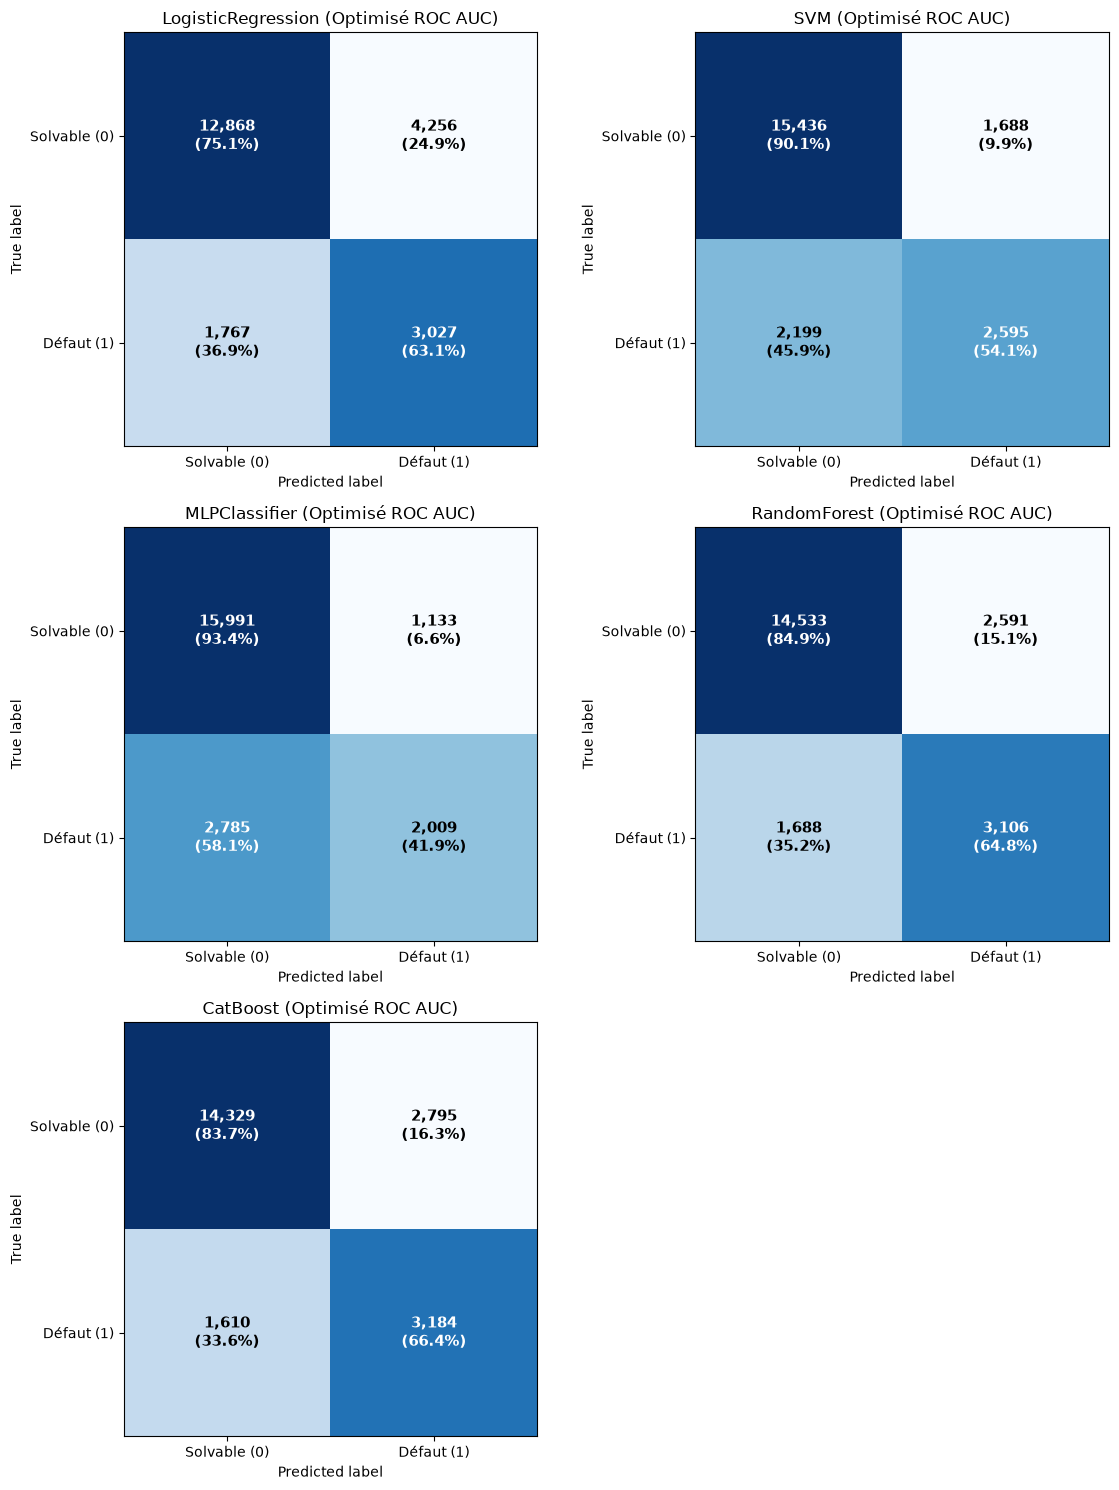


=== IMPORTANCE DES FEATURES (Optimisé F1-Score) ===
           LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1                   25.05          12.63         32.46     30.90        25.26
LIMIT_BAL                9.31           7.41          5.00      8.34         7.52
PAY_3                    5.92           5.73         10.65      3.41         6.43
PAY_2                    0.36           7.82         14.93      2.10         6.30
BILL_AMT1                8.30           4.88          1.28      7.10         5.39
PAY_AMT1                 5.48           5.18          3.80      4.57         4.76
PAY_AMT2                 6.82           4.66          2.88      4.26         4.65
PAY_4                    1.83           3.12          9.09      2.40         4.11
MARRIAGE                 9.48           5.25          0.09      1.03         3.96
PAY_5                    1.85           4.60          6.03      1.52         3.50
PAY_6                    0.47           5.53 

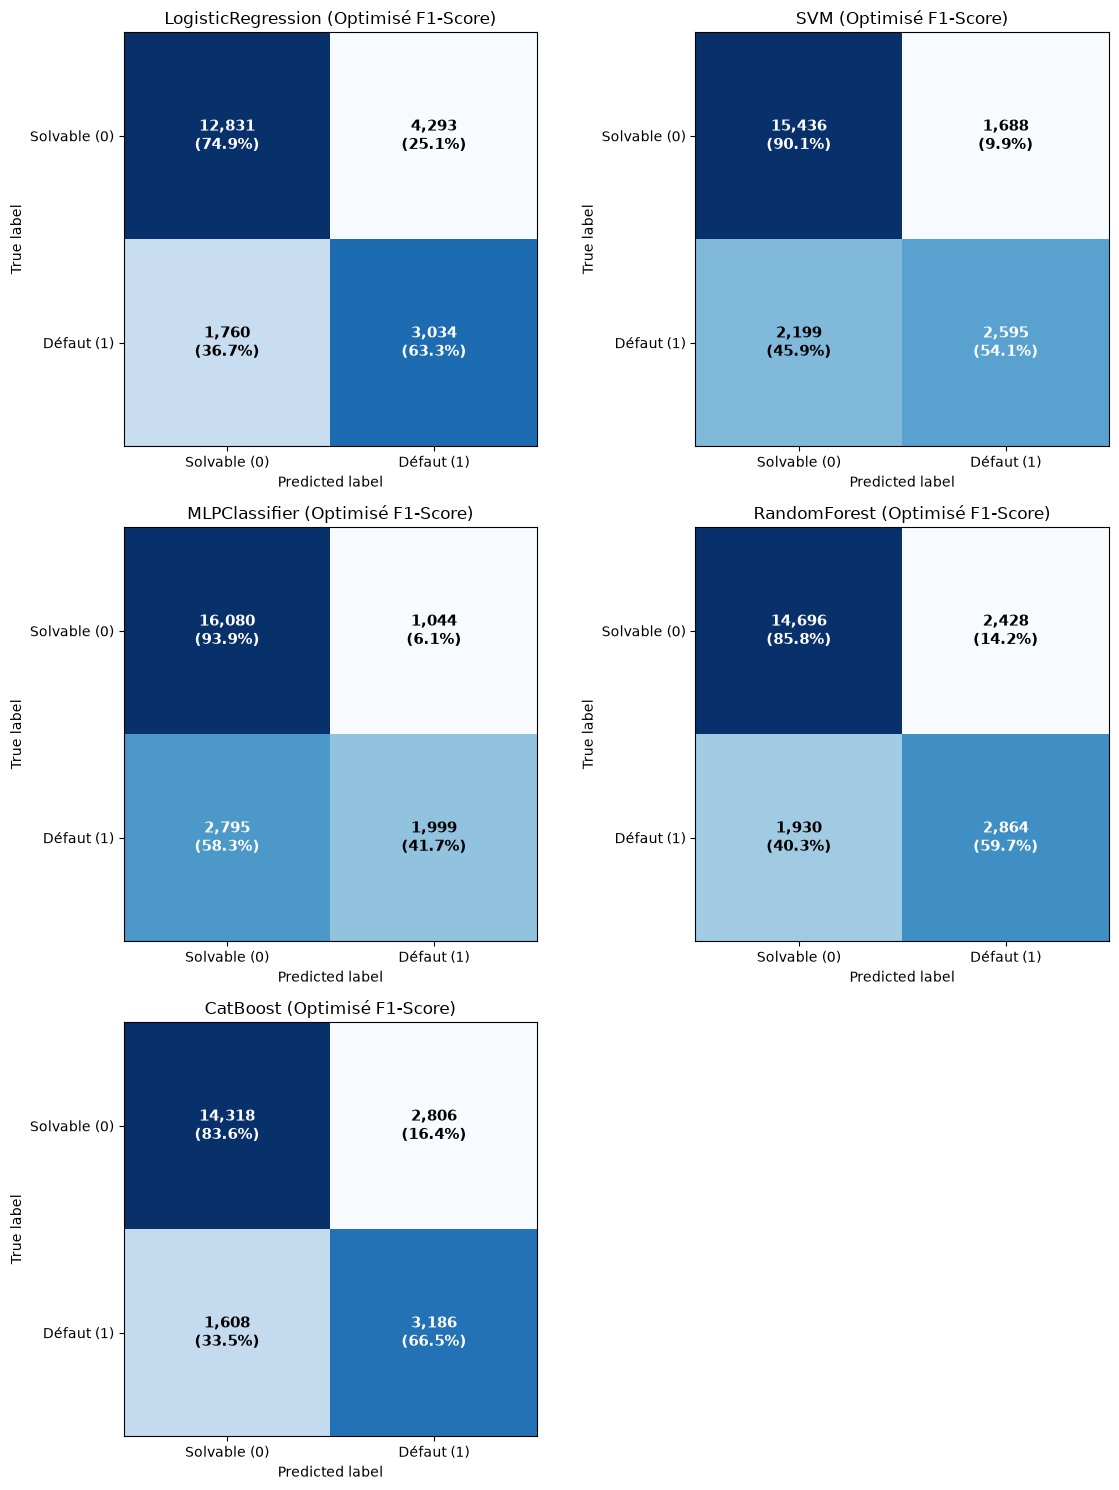

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


def analyser_modeles(dict_modeles, titre_metric):
    # A. Importances de variables
    importances_dict = {}

    for name, model in dict_modeles.items():
        clf = model[-1]

        if isinstance(clf, CalibratedClassifierCV):
            clf_estimator = (
                clf.calibrated_classifiers_[0].estimator
                if hasattr(clf, "calibrated_classifiers_")
                else clf.estimator
            )
        else:
            clf_estimator = clf

        if hasattr(clf_estimator, "feature_importances_"):
            raw_imp = clf_estimator.feature_importances_
        elif hasattr(clf_estimator, "coef_"):
            raw_imp = np.abs(clf_estimator.coef_[0])
        elif hasattr(clf_estimator, "coefs_"):
            raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
        else:
            continue

        total = raw_imp.sum()
        importances_dict[name] = (
            (raw_imp / total) * 100 if total > 0 else raw_imp
        )

    df_imp = pd.DataFrame(importances_dict, index=num_col + cat_col)
    if not df_imp.empty:
        df_imp["Moyenne (%)"] = df_imp.mean(axis=1)
        df_imp = df_imp.sort_values(by="Moyenne (%)", ascending=False).round(2)

        print(f"\n=== IMPORTANCE DES FEATURES ({titre_metric}) ===")
        print(df_imp.to_string())

    # B. Matrices de confusion + Stockage des Rappels Train
    n_models = len(dict_modeles)
    n_cols = 2 if n_models > 1 else 1
    n_rows = (n_models + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten() if n_models > 1 else [axes]

    recalls_train = {}  # Dictionnaire pour stocker les rappels calculés

    for idx, (name, model) in enumerate(dict_modeles.items()):
        # Calcul des prédictions et de la matrice
        y_pred = model.predict(X_train)
        cm = confusion_matrix(y_train, y_pred)

        # Taux de correspondance par classe réelle (ligne)
        cm_rate = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

        # Récupération directe du Recall Train (Ligne 1, Colonne 1)
        recalls_train[name] = cm_rate[1, 1]

        # Contours du graphique sans le texte automatique du composant
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm_rate,
            display_labels=["Solvable (0)", "Défaut (1)"],
        )
        disp.plot(
            cmap="Blues",
            ax=axes[idx],
            colorbar=False,
            include_values=False,
        )

        # Injection propre de tes 2 valeurs uniquement : Effectif + % par classe
        for i in range(2):
            for j in range(2):
                count = cm[i, j]
                rate = cm_rate[i, j]
                text_label = f"{count:,}\n({rate:.1%})"

                color = "white" if rate > 0.5 else "black"
                axes[idx].text(
                    j,
                    i,
                    text_label,
                    ha="center",
                    va="center",
                    color=color,
                    fontweight="bold",
                    fontsize=11,
                )

        axes[idx].set_title(f"{name} ({titre_metric})")

    for idx in range(n_models, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

    # On retourne le dictionnaire des rappels d'entraînement
    return recalls_train


# Exécution et récupération des rappels
recalls_train_auc = analyser_modeles(best_models_auc, "Optimisé ROC AUC")
recalls_train_f1 = analyser_modeles(best_models_f1, "Optimisé F1-Score")

MLPClassifier semble doué pour détecter les vrais clients solvables, ce qui n'est pas le but recherché ici, il ne peut pas compenser via un hyperparamètre le déséquilibre de classe, on pourrait lui diminuer le seuil de décision ou faire un entrainement particulier compute_sample_weight pour compenser le déséquilibre

## Test final sur X_test

In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, recall_score, roc_auc_score

print("=== ÉVALUATION FINALE MULTI-TABLEAUX (X_TEST VS CV & TRAIN) ===\n")


def generer_tableaux_analyse(
    dict_best_models, df_cv_results, dict_recalls_train, metric_name
):
    cv_map = df_cv_results.set_index("Modèle")

    target_rows = []
    recall_rows = []

    for model_name, model in dict_best_models.items():
        # 1. Prédictions sur X_test
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        # 2. Métriques sur Test
        test_target = (
            roc_auc_score(y_test, y_pred_proba)
            if metric_name == "ROC AUC"
            else f1_score(y_test, y_pred)
        )
        test_recall = recall_score(y_test, y_pred)

        # 3. Récupération du score CV et du Recall Train (issu de la cellule précédente)
        cv_target = cv_map.loc[model_name, "Score Val"]
        train_recall = dict_recalls_train.get(model_name, np.nan)

        # 4. Calcul des écarts
        diff_target = test_target - cv_target
        diff_recall = (
            (test_recall - train_recall) if pd.notna(train_recall) else np.nan
        )

        # Diagnostics
        diag_target = (
            "⚠️ Overfit"
            if diff_target < -0.05
            else ("📈 Sous-estimé" if diff_target > 0.05 else "✅ Stable")
        )
        diag_recall = (
            "⚠️ Chute Rappel"
            if pd.notna(diff_recall) and diff_recall < -0.04
            else "✅ Stable"
        )

        # Tableau 1 : Métrique Cible
        target_rows.append(
            {
                "Modèle": model_name,
                f"{metric_name} (CV)": round(cv_target, 4),
                f"{metric_name} (Test)": round(test_target, 4),
                "Diff Target": round(diff_target, 4),
                "Diagnostic": diag_target,
            }
        )

        # Tableau 2 : Métrique Rappel
        recall_rows.append(
            {
                "Modèle": model_name,
                "Recall (Train)": (
                    round(train_recall, 4) if pd.notna(train_recall) else "N/A"
                ),
                "Recall (Test)": round(test_recall, 4),
                "Diff Recall": (
                    round(diff_recall, 4) if pd.notna(diff_recall) else "N/A"
                ),
                "Diagnostic": diag_recall,
            }
        )

    return pd.DataFrame(target_rows), pd.DataFrame(recall_rows)


# ---------------------------------------------------------
# A. BLOC OPTIMISÉ POUR F1-SCORE
# ---------------------------------------------------------
df_f1_target, df_f1_recall = generer_tableaux_analyse(
    best_models_f1, df_results_f1, recalls_train_f1, "F1 Score"
)

print("=" * 65)
print("🎯 1. OPTIMISATION : F1-SCORE")
print("=" * 65)

print("\n--- Tableau 1A : Stabilité Métrique Cible (F1-Score) ---")
print(df_f1_target.to_string(index=False))

print("\n--- Tableau 1B : Dérive du Rappel (Recall Train vs Test) ---")
print(df_f1_recall.to_string(index=False))

print("\n\n")

# ---------------------------------------------------------
# B. BLOC OPTIMISÉ POUR ROC AUC
# ---------------------------------------------------------
df_auc_target, df_auc_recall = generer_tableaux_analyse(
    best_models_auc, df_results_auc, recalls_train_auc, "ROC AUC"
)

print("=" * 65)
print("🎯 2. OPTIMISATION : ROC AUC")
print("=" * 65)

print("\n--- Tableau 2A : Stabilité Métrique Cible (ROC AUC) ---")
print(df_auc_target.to_string(index=False))

print("\n--- Tableau 2B : Dérive du Rappel (Recall Train vs Test) ---")
print(df_auc_recall.to_string(index=False))

=== ÉVALUATION FINALE MULTI-TABLEAUX (X_TEST VS CV & TRAIN) ===

🎯 1. OPTIMISATION : F1-SCORE

--- Tableau 1A : Stabilité Métrique Cible (F1-Score) ---
            Modèle  F1 Score (CV)  F1 Score (Test)  Diff Target Diagnostic
LogisticRegression         0.5021           0.4938      -0.0083   ✅ Stable
               SVM         0.5437           0.5407      -0.0030   ✅ Stable
     MLPClassifier         0.5130           0.4931      -0.0199   ✅ Stable
      RandomForest         0.5576           0.5617       0.0041   ✅ Stable
          CatBoost         0.5535           0.5560       0.0025   ✅ Stable

--- Tableau 1B : Dérive du Rappel (Recall Train vs Test) ---
            Modèle  Recall (Train)  Recall (Test)  Diff Recall      Diagnostic
LogisticRegression          0.6329         0.6264      -0.0065        ✅ Stable
               SVM          0.5413         0.5071      -0.0342        ✅ Stable
     MLPClassifier          0.4170         0.4037      -0.0133        ✅ Stable
      RandomForest  

Pas de surapprentissage  
Attention : le recall sur MLPClassifier est dégradé, le réseau de neurones est à traiter peut etre à part  
Déperdition de recall sur les meilleurs modèles